<a href="https://colab.research.google.com/github/MNTech955/100-days-of-machine-learning/blob/main/Outlier__Detection__using__the__Percentile__Method.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv('sample_data/weight-height.csv')

df.head()

df.shape

(10000, 3)

In [2]:
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [3]:
df['Height'].describe()

,Height
count,10000.000000
mean,66.367560
std,3.847528
min,54.263133
25%,63.505620
50%,66.318070
75%,69.174262
max,78.998742


In [10]:
import seaborn as sns
import matplotlib.pyplot as plt


/tmp/ipykernel_41525/3945773010.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Height'])


<Axes: xlabel='Height', ylabel='Density'>

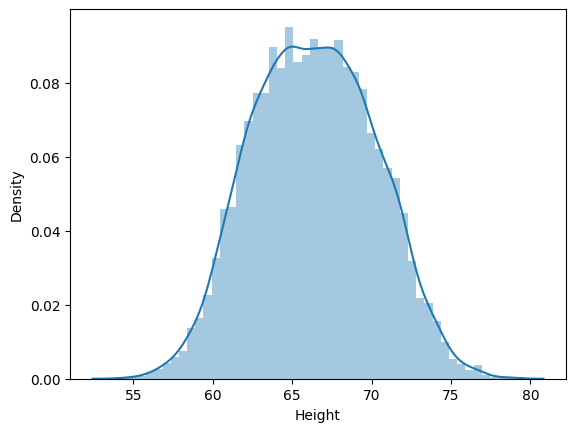

In [5]:
sns.distplot(df['Height'])

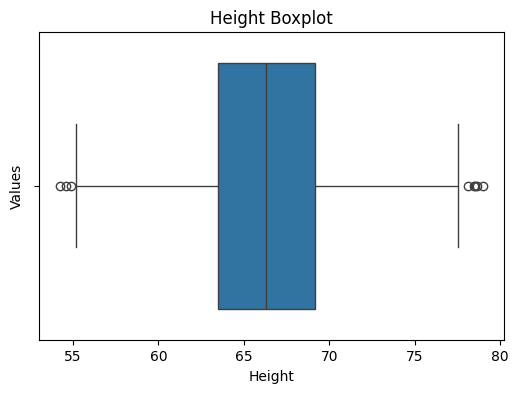

In [11]:
fig, ax = plt.subplots(figsize=(6,4))  # single axis

# Boxplot ko is axis par plot karna
sns.boxplot(x=df['Height'], ax=ax)

# Title aur labels
ax.set_title('Height Boxplot')
ax.set_xlabel('Height')
ax.set_ylabel('Values')

plt.show()

In [12]:
upper_limit = df['Height'].quantile(0.99)
upper_limit

np.float64(74.7857900583366)

In [13]:
lower_limit = df['Height'].quantile(0.01)
lower_limit

np.float64(58.13441158671655)

In [14]:
new_df = df[(df['Height'] <= 74.78) & (df['Height'] >= 58.13)]

In [15]:
new_df['Height'].describe()

,Height
count,9799.000000
mean,66.363507
std,3.644267
min,58.134496
25%,63.577147
50%,66.317899
75%,69.119859
max,74.767447


In [16]:
df['Height'].describe()

,Height
count,10000.000000
mean,66.367560
std,3.847528
min,54.263133
25%,63.505620
50%,66.318070
75%,69.174262
max,78.998742


/tmp/ipykernel_41525/1622920233.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df['Height'])


<Axes: xlabel='Height', ylabel='Density'>

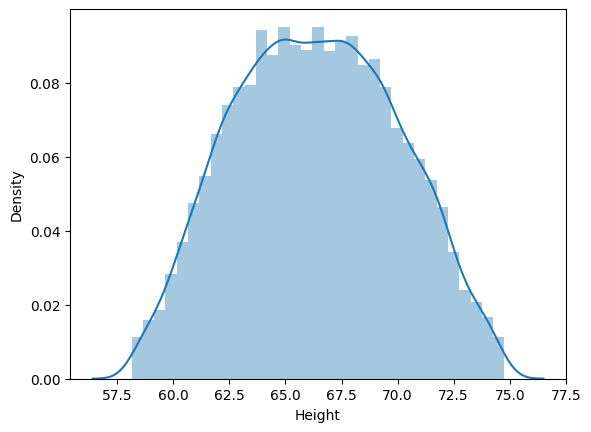

In [17]:
sns.distplot(new_df['Height'])

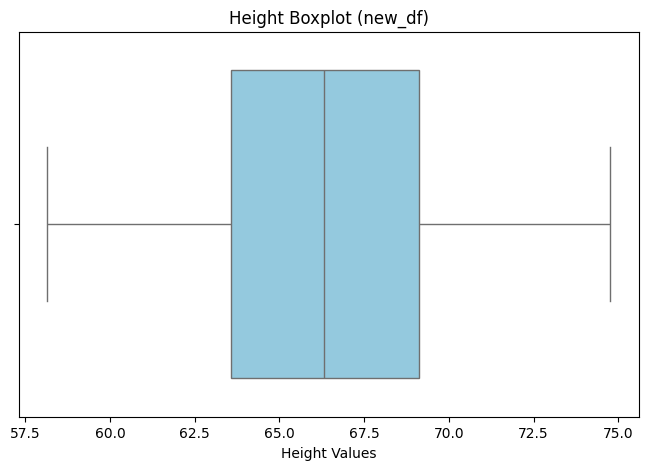

In [18]:
# Figure size define karna
plt.figure(figsize=(8,5))

# Boxplot draw karna
sns.boxplot(x=new_df['Height'], color='skyblue')  # horizontal boxplot

# Title aur labels
plt.title('Height Boxplot (new_df)')
plt.xlabel('Height Values')

plt.show()

In [19]:
# Capping --> Winsorization
df['Height'] = np.where(df['Height'] >= upper_limit,
        upper_limit,
        np.where(df['Height'] <= lower_limit,
        lower_limit,
        df['Height']))

In [20]:
df.shape

(10000, 3)

In [21]:
df['Height'].describe()

,Height
count,10000.000000
mean,66.366281
std,3.795717
min,58.134412
25%,63.505620
50%,66.318070
75%,69.174262
max,74.785790


/tmp/ipykernel_41525/3945773010.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Height'])


<Axes: xlabel='Height', ylabel='Density'>

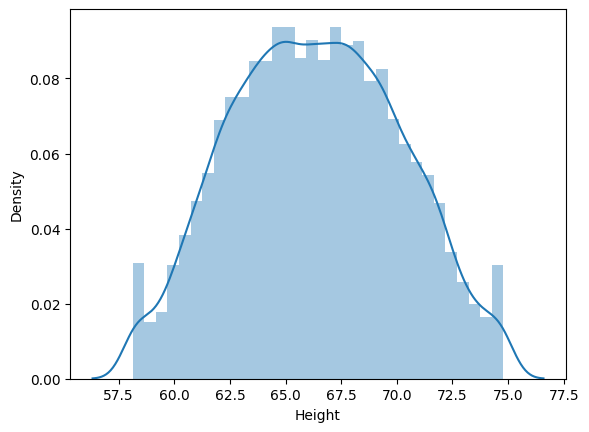

In [22]:
sns.distplot(df['Height'])

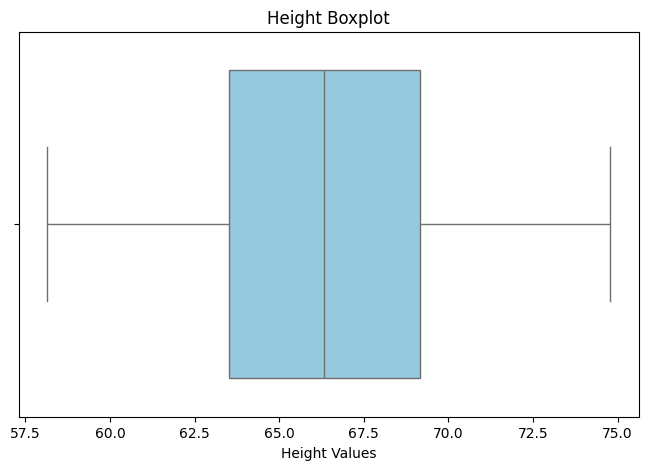

In [23]:
# Figure size
plt.figure(figsize=(8,5))

# Boxplot
sns.boxplot(x=df['Height'], color='skyblue')

# Title aur labels
plt.title('Height Boxplot')
plt.xlabel('Height Values')

# Show the plot
plt.show()